In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as intg
from IPython.display import clear_output

from H2O2_formation import rate_const_H2O2

In [2]:
#calculating the number of reaction sites: NSA_Pt
A_Pt=1*(10**-4)  #area of 1 cm² in m²
SD_Pt111=1.52*(10**15)*10**4  #atoms/m²
NSA_Pt=A_Pt*SD_Pt111 #absolute number of reaction sites present in 1 cm² of catalyst

In [3]:
M_F=18.998E-3  #molar mass of fluoride in kg/mol
h_memb_117=183E-6

#the data in the loaded files was extracted from diagrams in the literature
FER_data_L=np.loadtxt("./Laconti_FER.txt") #[0:6] 1/T, [6:12] FER in µg/hr/cm², [12:14] x-values regression line, [14:16] y-values regression line
FER_data_C=np.loadtxt("./Chandesris_FER.txt")  #60 °C [0:6] curden in A/cm² and [6:12] FER in µg/hr/cm², 80°C [12:15] curden in A/cm² and [15:18] FER in µg/hr/cm²

#the fluoride-emissions are given in µg/hr/cm² -> conversion to mol/l/s
FER_data_L[6:12]=FER_data_L[6:12]*10**4/(M_F*h_memb_117*3600*10**9*1000)  #both papers used Nafion 117
FER_data_L[14:16]=FER_data_L[14:16]*10**4/(M_F*h_memb_117*3600*10**9*1000)
FER_data_C[6:12]=FER_data_C[6:12]*10**4/(M_F*h_memb_117*3600*10**9*1000)
FER_data_C[15:18]=FER_data_C[15:18]*10**4/(M_F*h_memb_117*3600*10**9*1000)

In [4]:
#Nafion is C7HF13O5S.(C2F4)m with m being about 6, therefore 37 F per sulfonate acid group
EW=1.1  #equivalent weight of Nafion in kg/mol (weight of dry Nafion per mol of sulfonate acid groups)
M_F=18.998E-3  #molar mass of fluoride in kg/mol
m_F=37*M_F  #mass of fluoride = 0.703 kg per mol acid group
density_Nafion=1675  #density of water-swollen Nafion in kg/m³, from DOI: 10.1016/0376-7388(92)85007-6
density_F=density_Nafion*0.673  #m_F/EW  #m_F/EW is the relative contribution of fluoride to the whole weight, hence the density of
                                 #fluoride is the density of the polymer times this ratio; density given in kg/m³
c_F=density_F/(M_F*1000)  #fluoride concentration in Nafion in mol/l
print("Fluoride concentration: "+str(c_F)+" mol/l")

Fluoride concentration: 59.33650910622171 mol/l


In [21]:
#assignment of functions "rxn", "gas_trans", "deg_rate" and "H2_price"

#constants
m_H=2*1.66e-27  #mass of H2 in kg
M_H2=2e-3  #molar mass of H2 in kg/mol
m_O=32*1.66e-27  #mass of O2 in kg
m_H2O=18*1.66e-27  #mass of H2O in kg
M_H2O=18e-3  #molar mass of water in kg/mol
density_H2O=980  #density of water in kg/m³; changes with temperature, therefore this value as a compromise
EW=1.1  #equivalent weight of Nafion in kg/mol

kbT=1.38e-23  #Boltzmann constant in J/K
R=8.314  #gas constant in J/mol/K
N_A=6.022e23  #Avogadro constant in 1/mol
F=9.648e4  #Faraday constant in As/mol

T_0=1100  #the temperature in K at which the sticking coefficients were meassured
S_H2_0=0.05  #sticking coefficient for hydrogen at 1100 K
S_O2_0=0.02  #sticking coefficient for oxygen at 1100 K

h_decay=20e-9  #decay length of *OH in m, from 10.1149/1.3581040
V_decay=h_decay*1e-7

#this function takes T and curden and outputs values concerning H2 and O2
def gas_trans(T,curden,P_cat,P_an,h_memb):
    P_cat_H2=[P_cat]
    P_an_O2=[P_an]
#     i=0
#     while i<10:
#         #hydrogen and oxygen pressure at cathode and anode respectively
#         P_cat_H2.append(P_cat+24*(4.65e-14*P_cat_H2[i]+2e-14*(P_cat_H2[i]-P_an_O2[i]))*curden/(4.65e-14*P_cat_H2[i]))
#         P_an_O2.append(P_an+28*curden)
#         i+=1
    
    #formation rates
    f_H2=curden/(2*F)  #hydrogen formation rate in mol/m²*s
    f_O2=curden/(4*F)  #oxygen formation rate in mol/m²*s
    
    #water speed through the membrane
    v_H2O=(-0.332*np.log10(curden)+5.59)*M_H2O*curden/(2*F*density_H2O)  #velocity of water in m/s; depending on current density
    v_H2O=v_H2O*h_memb/(178e-6)
    
    #diffusion (dif_coeff from 10.1016/j.ijhydene.2011.05.127)
    dif_coeff_H2=2.51e-05*np.exp(-16.51e3/(R*T))  #diffusion coefficient in m²/s
    dif_coeff_O2=1.90e-05*np.exp(-18.38e3/(R*T))
    sol_H2=0.72e-6  #solubility in mol/m³*Pa
    sol_O2=0.8e-6
    s_O2=sol_O2*P_an/1000  #solubility of O2 in Nafion in mol/l
    flux_dif_H2=dif_coeff_H2*sol_H2*P_cat_H2[-1]/h_memb  #diffusion flux in mol/m²*s
    flux_dif_O2=dif_coeff_O2*sol_O2*P_an_O2[-1]/h_memb
    #flux_dif_H2=4.65e-14*P_cat_H2[-1]/h_memb
    #flux_dif_O2=2e-14*P_an_O2[-1]/h_memb
        
    #drag
    drag_coeff=0.0134*T+0.03  #dimensionless drag coefficient
    c_H2O=40e3  #water concentration in Nafion in mol/m³
    flux_drag_H2=-0.13*np.log10(curden)*drag_coeff*P_cat_H2[-1]*sol_H2/(F*c_H2O)  #drag flux in mol/m²*s
    flux_drag_O2=0.13*np.log10(curden)*drag_coeff*P_an_O2[-1]*sol_O2/(F*c_H2O)
        
    #differential pressure
    flux_dp_H2=2e-14*(P_cat_H2[-1]-P_an_O2[-1])/h_memb  #dp flux in mol/m²*s
    flux_dp_O2=2e-14*(P_an_O2[-1]-P_cat_H2[-1])/h_memb
            
    #total flux
    flux_H2=flux_dif_H2+flux_dp_H2+flux_drag_H2  #total hydrogen flux in mol/m²*s
    flux_O2=flux_dif_O2+flux_dp_O2+flux_drag_O2  #total oxygen flux in mol/m²*s
    if flux_H2>f_H2:
        flux_H2=f_H2  #more H2 permeating than being created not possible
    if flux_O2>f_O2:
        flux_O2=f_O2  #more O2 permeating than being created not possible
    if flux_O2<0:
        flux_O2=0
        
    #ratios
    H2_in_O2=100*flux_H2/(flux_H2+f_O2)
    O2_in_H2=100*flux_O2/(flux_O2+f_H2)
    alpha=f_H2/(flux_O2+f_H2)
    
    #calculation of H2 and O2 source terms and concentrations
    r_H2=f_H2/(h_cat*1000)  #H2 rate in mol/l/s 
    r_O2=flux_O2/(h_memb*1000)  #O2 rate in mol/l/s
    
    c_H2=sol_H2*P_cat/1000  #H2 concentration in mol/l; set to the solubility because of massive H2 abundance
    c_O2=flux_O2/(v_H2O*1000)  #O2 concentration in mol/l
    if c_O2>s_O2:
        c_O2=s_O2  #concentration can't exceed solubility
    if c_O2<0:
        c_O2=0
    
    return [alpha, r_H2, r_O2, v_H2O, c_H2, c_O2, f_H2, O2_in_H2]

#Defining the seperated reaction network
def rxn_separate(Z,t):    
    #chemical part
    r1 = 2*Z_S_H*A_Pt*S_H2*(1-(Z[0]+Z[1]+Z[2]+Z[3])/NSA_Pt)        # H2_g -> 2H_a
    r_1= 2*k_1*((Z[0]/NSA_Pt)**2)                                  # H2_g <- 2H_a
    r2 = 2*Z_S_O*A_Pt*S_O2*(1-(Z[0]+Z[1]+Z[2]+Z[3])/NSA_Pt)        # O2_g -> 2O_a
    r_2= 2*k_2*((Z[1]/NSA_Pt)**2)                                  # O2_g <- 2O_a
    r3 = k3*(Z[0]/NSA_Pt)*(Z[1]/NSA_Pt)                            # H_a + O_a -> OH_a
    r_3= k_3*(Z[2]/NSA_Pt)*(1-(Z[0]+Z[1]+Z[2]+Z[3])/NSA_Pt)        # H_a + O_a <- OH_a
    r4 = k4*(Z[0]/NSA_Pt)*(Z[2]/NSA_Pt)                            # H_a + OH_a -> H2O_a
    r_4= k_4*(Z[3]/NSA_Pt)*(1-(Z[0]+Z[1]+Z[2]+Z[3])/NSA_Pt)        # H_a + OH_a <- H2O_a
    r5 = k5*((Z[2]/NSA_Pt)**2)                                     # OH_a + OH_a -> H2O_a + O_a 
    r_5= k_5*(Z[3]/NSA_Pt)*(Z[1]/NSA_Pt)                           # OH_a + OH_a <- H2O_a + O_a
    r6 = k6*(Z[2]/NSA_Pt)                                          # OH_a -> OH*
    r7 = k7*(Z[3]/NSA_Pt)                                          # H2O_a -> H2O_g
    r8 = k21*(Z[4]/(N_A*V_decay*1000))*c_COOH                      # OH* + COOH -> products
    #        conversion from 1 in mol/l
    
    
    #electrochemical part
    r9  = ((k9*((Z[13]*1000)**2)*(Z[8]*1000))/h_cat)/1000  # 2 proton + O2_g -> H2O2_g
    
    #fenton reactions
    r10 = k10*Z[10]*Z[11]*Z[13]  # H2O2_g + Fe2 + proton -> OH* + H2O_g + Fe3                                         
    r11 = k11*Z[15]*Z[11]*Z[13]  # OH* + Fe2 + proton -> H2O_g + Fe3
    r12 = k12*Z[14]*Z[11]*Z[13]  # HOO* + Fe2 + proton -> H2O2_g + Fe3
    r13 = k13*Z[14]*Z[12]        # HOO* + Fe3 -> O2_g + proton + Fe2
    r14 = k14*Z[10]*Z[12]        # H2O2_g + Fe3 -> HOO* + Fe2 + proton
    
    r15 = k15*Z[10]              # H2O2_g -> 2OH*
    r16 = k16*Z[10]*Z[15]        # H2O2_g + OH* -> HOO* + H2O_g
    r17 = k17*Z[10]*Z[14]        # H2O2_g + HOO* -> OH* + H2O_g + O2_g
    r18 = k18*Z[7]*Z[15]         # H2_g + OH* -> H* + H2O_g 
    r19 = k19*Z[8]*Z[16]         # O2_g + H* -> HOO*
    r20 = k20*(Z[14]**2)         # 2HOO* -> H2O2_g + O2_g
    
    r21 = k21*Z[15]*c_COOH       # OH* + COOH -> products
    
    #convection terms only for long living species
    conv7 = Z[7]*v_H2O/h_memb_1  #H2
    conv8 = Z[8]*v_H2O/h_memb_1  #O2
    conv9 = Z[9]*v_H2O/h_memb_1  #H2O
    conv10= Z[10]*v_H2O/h_memb_1  #H2O2
    conv11= Z[11]*v_H2O/h_memb_1  #Fe2
    conv12= Z[12]*v_H2O/h_memb_1  #Fe3
    
    #the concentrations change according to the following equations
    dd0dt = +r1+r_3+r_4-r_1-r3-r4         #H_a
    dd1dt = +r2+r_3+r5-r_2-r3-r_5         #O_a
    dd2dt = +r3+r_4+2*r_5-r_3-r4-2*r5-r6  #OH_a
    dd3dt = +r4+r5-r_4-r_5-r7             #H2O_a
    dd4dt = +r6-(r8*N_A*V_decay*1000)     #OH*
    dd5dt = +r7                           #H2O_g
    dd6dt = +r8                           #attacks
    
    dd7dt = 0# +r_H2-r18-conv7  #const.                       # H2_g
    dd8dt = +r_O2+r13+r17+r20-r9-r19-conv8                    # O2_g
    dd9dt = +r10+r11+r16+r17+r18-conv9                        # H2O_g
    dd10dt= +r9+r12+r20-r10-r14-r15-r16-r17-conv10            # H2O2_g
    dd11dt= +r_Fe2+r13+r14-r10-r11-r12-conv11                 # Fe2
    dd12dt= +r_Fe3+r10+r11+r12-r13-r14-conv12                 # Fe3
    dd13dt= 0# +r13+r14-2*r9-r10-r11-r12-r17  #const.         # proton
    dd14dt= +r14+r16+r19-r12-r13-2*r20                        # HOO*
    dd15dt= +r10+2*r15+r17-r11-r16-r18-r21                    # OH*
    dd16dt= +r18-r19                                          # H*
    dd17dt= +r21                                              # attacks
    
    global r_array
    r_array=np.array([r9,r10,r11,r12,r13,r14,r15,r16,r17,r18,r19,r20,r21])
    
    #    Z[H_a,   O_a,   OH_a,  H2O_a, OH*,   H2O_g,attacks,H2_g,  O2_g,  H2O_g, H2O2_g, Fe2+,   Fe3+,   proton,
    #      HOO*,   OH*,    H*,    attacks]
    return[dd0dt, dd1dt, dd2dt, dd3dt, dd4dt, dd5dt, dd6dt, dd7dt, dd8dt, dd9dt, dd10dt, dd11dt, dd12dt, dd13dt,
           dd14dt, dd15dt, dd16dt, dd17dt]
    
#Defining the cuppled reaction network
def rxn_cuppled(Z,t):
    global alpha, Z_S_O, trans_O2
    trans_O2 = (r_O2+Z[8])*1000*h_memb_1
    alpha = f_H2/(f_H2+trans_O2)
    Z_S_O = ((P_cat_1-alpha*P_cat_1)/m_O)*np.sqrt(m_O/(2*np.pi*kbT*T_1))
    
    #chemical part
    r1 = 2*Z_S_H*A_Pt*S_H2*(1-(Z[0]+Z[1]+Z[2]+Z[3])/NSA_Pt)        # H2_g -> 2H_a
    r_1= 2*k_1*((Z[0]/NSA_Pt)**2)                                  # H2_g <- 2H_a
    r2 = 2*Z_S_O*A_Pt*S_O2*(1-(Z[0]+Z[1]+Z[2]+Z[3])/NSA_Pt)        # O2_g -> 2O_a
    r_2= 2*k_2*((Z[1]/NSA_Pt)**2)                                  # O2_g <- 2O_a
    r3 = k3*(Z[0]/NSA_Pt)*(Z[1]/NSA_Pt)                            # H_a + O_a -> OH_a
    r_3= k_3*(Z[2]/NSA_Pt)*(1-(Z[0]+Z[1]+Z[2]+Z[3])/NSA_Pt)        # H_a + O_a <- OH_a
    r4 = k4*(Z[0]/NSA_Pt)*(Z[2]/NSA_Pt)                            # H_a + OH_a -> H2O_a
    r_4= k_4*(Z[3]/NSA_Pt)*(1-(Z[0]+Z[1]+Z[2]+Z[3])/NSA_Pt)        # H_a + OH_a <- H2O_a
    r5 = k5*((Z[2]/NSA_Pt)**2)                                     # OH_a + OH_a -> H2O_a + O_a 
    r_5= k_5*(Z[3]/NSA_Pt)*(Z[1]/NSA_Pt)                           # OH_a + OH_a <- H2O_a + O_a
    r6 = k6*(Z[2]/NSA_Pt)                                          # OH_a -> OH*
    r7 = k7*(Z[3]/NSA_Pt)                                          # H2O_a -> H2O_g
    r8 = k21*(Z[4]/(N_A*V_decay*1000))*c_COOH                      # OH* + COOH -> products
    #        conversion from 1 in mol/l
    
    
    #electrochemical part
    r9  = ((k9*((Z[13]*1000)**2)*(Z[8]*1000))/h_cat)/1000  # 2 proton + O2_g -> H2O2_g
    
    #fenton reactions
    r10 = k10*Z[10]*Z[11]*Z[13]  # H2O2_g + Fe2 + proton -> OH* + H2O_g + Fe3
    r11 = k11*Z[15]*Z[11]*Z[13]  # OH* + Fe2 + proton -> H2O_g + Fe3
    r12 = k12*Z[14]*Z[11]*Z[13]  # HOO* + Fe2 + proton -> H2O2_g + Fe3
    r13 = k13*Z[14]*Z[12]        # HOO* + Fe3 -> O2_g + proton + Fe2
    r14 = k14*Z[10]*Z[12]        # H2O2_g + Fe3 -> HOO* + Fe2 + proton
    
    r15 = k15*Z[10]              # H2O2_g -> 2OH*
    r16 = k16*Z[10]*Z[15]        # H2O2_g + OH* -> HOO* + H2O_g
    r17 = k17*Z[10]*Z[14]        # H2O2_g + HOO* -> OH* + H2O_g + O2_g
    r18 = k18*Z[7]*Z[15]         # H2_g + OH* -> H* + H2O_g
    r19 = k19*Z[8]*Z[16]         # O2_g + H* -> HOO*
    r20 = k20*(Z[14]**2)         # 2HOO* -> H2O2_g + O2_g
    
    r21 = k21*Z[15]*c_COOH       # OH* + COOH -> products
    
    #convection terms only for long living species
    conv7 = Z[7]*v_H2O/h_memb_1  #H2
    conv8 = Z[8]*v_H2O/h_memb_1  #O2
    conv9 = Z[9]*v_H2O/h_memb_1  #H2O
    conv10= Z[10]*v_H2O/h_memb_1  #H2O2
    conv11= Z[11]*v_H2O/h_memb_1  #Fe2
    conv12= Z[12]*v_H2O/h_memb_1  #Fe3
    
    #the concentrations change according to the following equations
    dd0dt = +r1+r_3+r_4-r_1-r3-r4         #H_a
    dd1dt = +r2+r_3+r5-r_2-r3-r_5         #O_a
    dd2dt = +r3+r_4+2*r_5-r_3-r4-2*r5-r6  #OH_a
    dd3dt = +r4+r5-r_4-r_5-r7             #H2O_a
    dd4dt = +r6-(r8*N_A*V_decay*1000)     #OH*
    dd5dt = +r7                           #H2O_g
    dd6dt = +r8                           #attacks
    
    dd7dt = 0# +r_H2-r18-conv7  #const.                       # H2_g
    dd8dt =((+r_O2+r13+r17+r20)-r9-r19-conv8
            +(r_2/(N_A*V_memb*1000))
            -(r2/(N_A*V_memb*1000)))                          # O2_g; r2 is in 1/s therefore conversion necessary
    dd9dt = +r10+r11+r16+r17+r18-conv9                        # H2O_g
    dd10dt= +r9+r12+r20-r10-r14-r15-r16-r17-conv10            # H2O2_g
    dd11dt= +r_Fe2+r13+r14-r10-r11-r12-conv11                 # Fe2
    dd12dt= +r_Fe3+r10+r11+r12-r13-r14-conv12                 # Fe3
    dd13dt= 0# +r13+r14-2*r9-r10-r11-r12-r17  #const.         # proton
    dd14dt= +r14+r16+r19-r12-r13-2*r20                        # HOO*
    dd15dt= +r10+2*r15+r17-r11-r16-r18-r21                    # OH*
    dd16dt= +r18-r19                                          # H*
    dd17dt= +r21                                              # attacks

    global r_array
    r_array=np.array([r9,r10,r11,r12,r13,r14,r15,r16,r17,r18,r19,r20,r21])
    
    #    Z[H_a,   O_a,   OH_a,  H2O_a, OH*,   H2O_g,attacks,H2_g,  O2_g,  H2O_g, H2O2_g, Fe2+,   Fe3+,   proton,
    #      HOO*,   OH*,    H*,    attacks]
    return[dd0dt, dd1dt, dd2dt, dd3dt, dd4dt, dd5dt, dd6dt, dd7dt, dd8dt, dd9dt, dd10dt, dd11dt, dd12dt, dd13dt,
           dd14dt, dd15dt, dd16dt, dd17dt]

def deg_rate(T,curden,P_cat,P_an,h_memb,f_Fe,pre_k9):
    #impingement rates f(T,curden,P_cat,P_an,h_memb)
    global Z_S_H, Z_S_O
    Z_S_H=(gas_trans(T,curden,P_cat,P_an,h_memb)[0]*P_cat/m_H)*np.sqrt(m_H/(2*np.pi*kbT*T))  #impingement rate of hydrogen at temperature T in 1/s/m²
    Z_S_O=((P_cat-gas_trans(T,curden,P_cat,P_an,h_memb)[0]*P_cat)/m_O)*np.sqrt(m_O/(2*np.pi*kbT*T))  #impingement rate of oxygen at temperature T in 1/s/m²
    
    #sticking coefficients f(T)
    global S_H2, S_O2
    S_H2=(S_H2_0*T_0)/T  #sticking coefficient of hydrogen at temperature T
    S_O2=(S_O2_0*T_0)/T  #sticking coefficient of oxygen at temperature T

    #gas_trans outputs f(T,curden,P_cat,P_an,h_memb)
    global r_H2, r_O2, c_H2, c_O2, v_H2O, f_H2, r_Fe2, r_Fe3
    r_H2=gas_trans(T,curden,P_cat,P_an,h_memb)[1]  #source rate of H2 in mol/l/s
    r_O2=0.01*gas_trans(T,curden,P_cat,P_an,h_memb)[2]  #source rate of O2 in mol/l/s
    c_H2=gas_trans(T,curden,P_cat,P_an,h_memb)[4]  #H2 concentration in mol/l from Gubler
    c_O2=gas_trans(T,curden,P_cat,P_an,h_memb)[5]  #7.5E-3  #O2 concentration in mol/l from Gubler
    v_H2O=gas_trans(T,curden,P_cat,P_an,h_memb)[3]  #water speed in m/s
    f_H2=gas_trans(T,curden,P_cat,P_an,h_memb)[6]  #hydrogen formation rate in mol/m²/s
    r_Fe2=f_Fe*v_H2O  #source term for Fe2+ in mol/l/s
    r_Fe3=f_Fe*v_H2O  #source term for Fe3+ in mol/l/s
    
    #reaction constants f(T)
    global k_1, k_2, k3, k_3, k4, k_4, k5, k_5, k6, k7, k9, k10, k11, k12, k13, k14, k15, k16, k17, k18, k19, k20, k21
    v=10**13  #assumed preexponential factor in s**-1
    E=[0.7,2.5,0.35,0.345,0,0.975,0,0.98,1,0.42]  #from https://doi.org/10.1016/0021-9517(91)90258-6
    #E=[0.7,2.5,0.96,0.9,0.21,0.68,0.13,0.33,1,0.34]  #from https://doi.org/10.1021/ja003576x
    #E=[0.7,2.5,0.559,1.247,0.688,1.075,0.774,0.43,1,0.43]  #from https://doi.org/10.1016/0039-6028(90)90217-V
    #E=[0.7,2.5,0.35,0.9,0.688,1.075,0.774,0.43,1,0.43]
    
    E_d_H2=E[0]*1.60*(10**-19)  #all activation energies get converted to J
    k_1=v*np.exp(-E_d_H2/(kbT*T))  #reaction constant for H2 desorption in s**-1
    E_d_O2=E[1]*1.60*(10**-19)
    k_2=v*np.exp(-E_d_O2/(kbT*T))  #reaction constant for O2 desorption in s**-1
    E_f_OH=E[2]*1.60*(10**-19)
    k3=v*np.exp(-E_f_OH/(kbT*T))  #reaction constant for OH formation in s**-1
    E_dec_OH=E[3]*1.60*(10**-19)
    k_3=v*np.exp(-E_dec_OH/(kbT*T))  #reaction constant for OH decomposition in s**-1
    E_f1_H2O=E[4]*1.60*(10**-19)
    k4=v*np.exp(-E_f1_H2O/(kbT*T))  #reaction constant for H2O formation via route 1 in s**-1
    E_dec1_H2O=E[5]*1.60*(10**-19)
    k_4=v*np.exp(-E_dec1_H2O/(kbT*T))  #reaction constant for H2O decomposition via route 1 in s**-1
    E_f2_H2O=E[6]*1.60*(10**-19)
    k5=v*np.exp(-E_f2_H2O/(kbT*T))  #reaction constant for H2O formation via route 2 in s**-1
    E_dec2_H2O=E[7]*1.60*(10**-19)
    k_5=v*np.exp(-E_dec2_H2O/(kbT*T))  #reaction constant for H2O decomposition via route 2 in s**-1
    E_d_OH=E[8]*1.60*(10**-19)
    k6=v*np.exp(-E_d_OH/(kbT*T))  #reaction constant for OH desorption in s**-1
    E_d_H2O=E[9]*1.60*(10**-19)
    k7=v*np.exp(-E_d_H2O/(kbT*T))  #reaction constant for H2O desorption in s**-1
    #(k10-k21 from Gubler et al 2011)
    #k10-k14 fenton reactions
    k10=1.03E8*np.exp(-35.4E3/(R*T))  # H2O2_g + Fe2 + proton -> OH* + H2O_g + Fe3
    k11=8.68E9*np.exp(-9E3/(R*T))     # OH* + Fe2 + proton -> H2O_g + Fe3
    k12=2.74E13*np.exp(-42E3/(R*T))   # HOO* + Fe2 + proton -> H2O2 + Fe3
    k13=1.21E10*np.exp(-33E3/(R*T))   # HOO* + Fe3 -> O2_g + proton + Fe2
    k14=8.31E18*np.exp(-126E3/(R*T))  # H2O2_g + Fe3 -> HOO* + Fe2 + proton
    k15=1.09E13*np.exp(-200E3/(R*T))  # H2O2_g -> 2OH*
    k16=7.66E9*np.exp(-14E3/(R*T))    # H2O2_g + OH* -> HOO* + H2O_g
    k17=5.41E5*np.exp(-30E3/(R*T))    # H2O2_g + HOO* -> OH* + H2O_g + O2_g
    k18=4.3E7                         # H2_g + OH* -> H* + H2O_g
    k19=1.2E10                        # O2_g + H* -> HOO*
    k20=3.5E9*np.exp(-20.6E3/(R*T))   # 2HOO* -> H2O2_g + O2
    k21=1.35E7*np.exp(-6.5E3/(R*T))   # OH* + COOH -> products

    #rate_const_H2O2()[0] always gives an array of k9 against current density, [abs(j-curden).argmin()] to pick out the desired current density
    j=np.linspace(0,30000,10000)  #current density over which k9 is calculated (see H2O2_formation notebook)
    j[0]=j[1]
    k9=pre_k9*rate_const_H2O2(T,P_cat,P_an,h_memb)[0][abs(j-curden).argmin()]  # 2 proton + O2_g -> H2O2
    
    global T_1, h_memb_1, V_memb, P_cat_1
    T_1=T
    h_memb_1=h_memb
    V_memb=h_memb*1e-7  #membrane volume in m³
    P_cat_1=P_cat
    t = np.linspace(0,3000,100)
    t_step = t[1]-t[0]
    Z0=[0,0,0,0,0,0,0,c_H2,c_O2,0,0,c_Fe2,c_Fe3,c_proton,0,0,0,0]
    if cuppled==False:
        conc=intg.odeint(rxn_separate, Z0, t, rtol=4.0E-8, atol=1.0E-10)
    else:
        conc=intg.odeint(rxn_cuppled, Z0, t, rtol=4.0E-8, atol=1.0E-10)
    
    attack_rate_chem=np.diff(conc[:,6])[-1]/t_step
    attack_rate_elchem=np.diff(conc[:,17])[-1]/t_step
    attack_rate=(np.diff(conc[:,6])[-1]+np.diff(conc[:,17])[-1])/t_step
    return [attack_rate_chem, attack_rate_elchem, attack_rate, conc[-1,:], r_array]

def H2_price(T,curden,P_cat,P_an,h_memb,A,lifetime_h,energy_price):
    #rate_const_H2O2 is used to obtain the cell_voltage
    j=np.linspace(0,30000,10000)  #current density over which U_cell is calculated (see H2O2_formation notebook)
    j[0]=j[1]
    U_cell=rate_const_H2O2(T,P_cat,P_an,h_memb)[2][abs(j-curden).argmin()]

    time_h=np.linspace(0,lifetime_h,round(lifetime_h)+1)  #from BOl to EOL in hour steps
    eff_deg=2.5e-6  #efficiency degradation in V/h; average of 5 and 25 µV/h
    eff=1.48/(U_cell+eff_deg*time_h)  #efficiency over time from BOL as eff[0] until EOL as eff[-1]

    H2_kg_h=curden*A*M_H2*3600/(2*F)  #H2 production in kg/h
    H2_kg_LT=H2_kg_h*time_h[-1]  #H2 lifetime production in kg/h

    #capital expenditure
    CAPEX=60e3*A*1.75  #in € with 1.75 €/W
    
    #operational expenditure
    OPEX_pa=CAPEX*0.04  #annual maintenance cost
    OPEX=OPEX_pa*(time_h[-1]/8760)  #in €
    
    #energy price and consumption
    power=curden*A*(U_cell+eff_deg*time_h)  #in W, to facilitate constant curden, power has to be increased over time
    energy_consumed=np.cumsum(power*1)[-1]  #in Wh (time_h is in 1 hour steps)
    energy_cost=energy_price*energy_consumed  #in €
    
    #hydrogen cost
    price_H2=(energy_cost+CAPEX+OPEX)/H2_kg_LT  #H2 price in €/kg
    return [price_H2, H2_kg_LT, CAPEX, OPEX, energy_cost]

In [11]:
#temperature dependance
#parameters
cuppled=True                #specify if cuppled or separate
T=np.linspace(321,422,100)  #temperature in K
P_cat=6.7e5                 #cathode pressure in Pa
P_an=6.7e5                  #anode pressure in Pa
h_memb=183e-6               #membrane thickness in m
h_cat=10e-6                 #cathode thickness in m
h_an=10e-6                  #anode thickness in m

c_COOH=1.17                                  #concentration of COOH-endgroups in mol/l
c_Fe2=7.0E-8                                 #starting concentration of Fe2+ ions in mol/l
c_Fe3=7.0E-8                                 #starting concentration of Fe3+ ions in mol/l
c_proton=(1980+32.4*16)/(1+0.00648*16)/1000  #proton concentration in the ionomer in mol/l

#function execution
# 1. creating a list for each set of parameters
attack_rate1=[]
attack_rate2=[]
attack_rate3=[]
attack_rate4=[]
# attack_rate5=[]
# attack_rate6=[]
error_upper=[]
error_lower=[]
# 2. running the function deg_rate() with each set of parameters; the function only takes single values not lists or arrays, therefore this loop
i=0
while i<len(T):
    attack_rate1.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e1,1)[2])
    attack_rate2.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e0,1)[2])
    attack_rate3.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e-1,1)[2])
    attack_rate4.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e-2,1)[2])
    # attack_rate5.append(deg_rate(T[i],1000,P_cat,P_an,h_memb,1e-2,1)[2])
    # attack_rate6.append(deg_rate(T[i],20000,P_cat,P_an,h_memb,1e-2,1)[2])
    error_upper.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e0,2.46)[2])
    error_lower.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e0,0.34)[2])
    clear_output(wait=True)
    print(i)
    i+=1
# 3. converting the lists to np.arrays for better handling
attack_rate1=np.array(attack_rate1)
attack_rate2=np.array(attack_rate2)
attack_rate3=np.array(attack_rate3)
attack_rate4=np.array(attack_rate4)
# attack_rate5=np.array(attack_rate5)
# attack_rate6=np.array(attack_rate6)
error_upper=np.array(error_upper)
error_lower=np.array(error_lower)

99


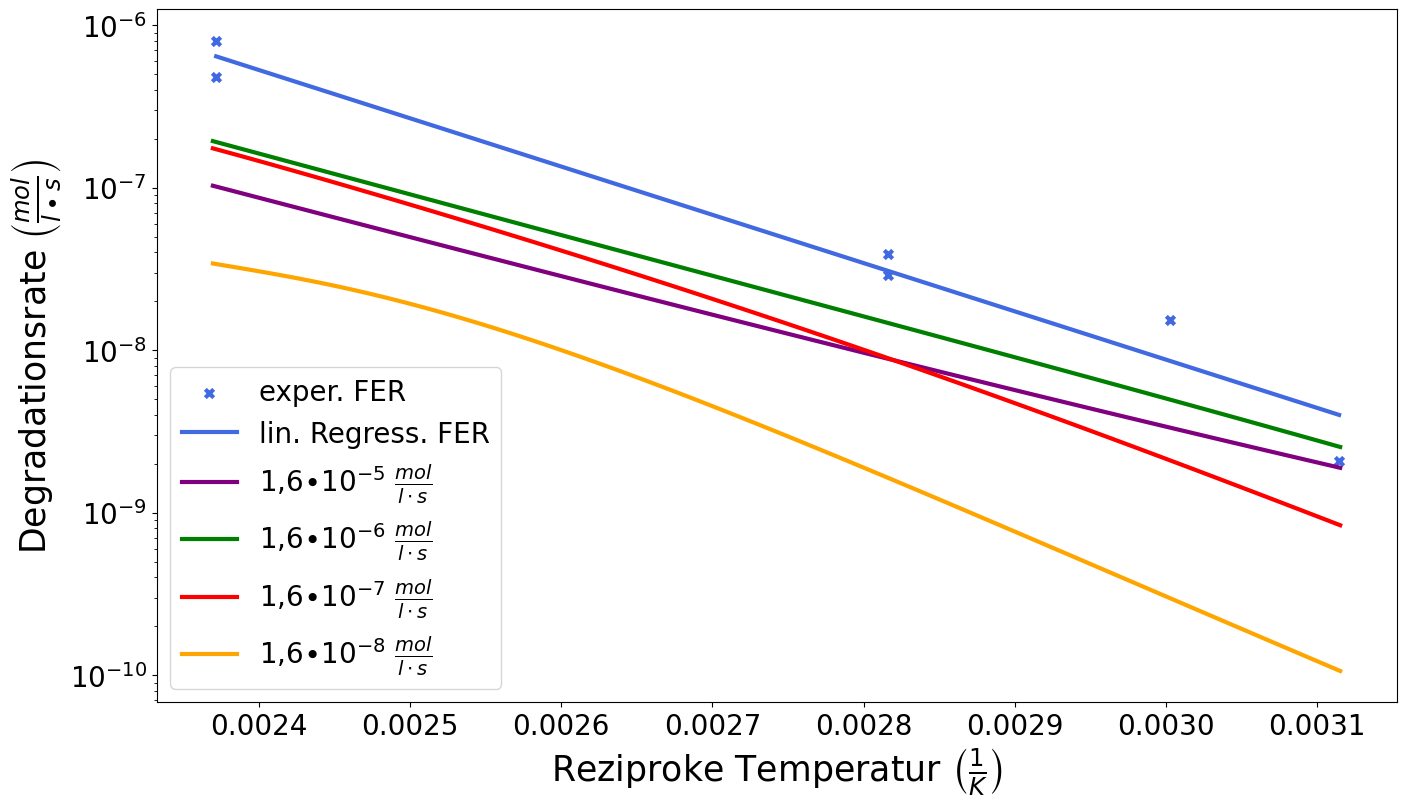

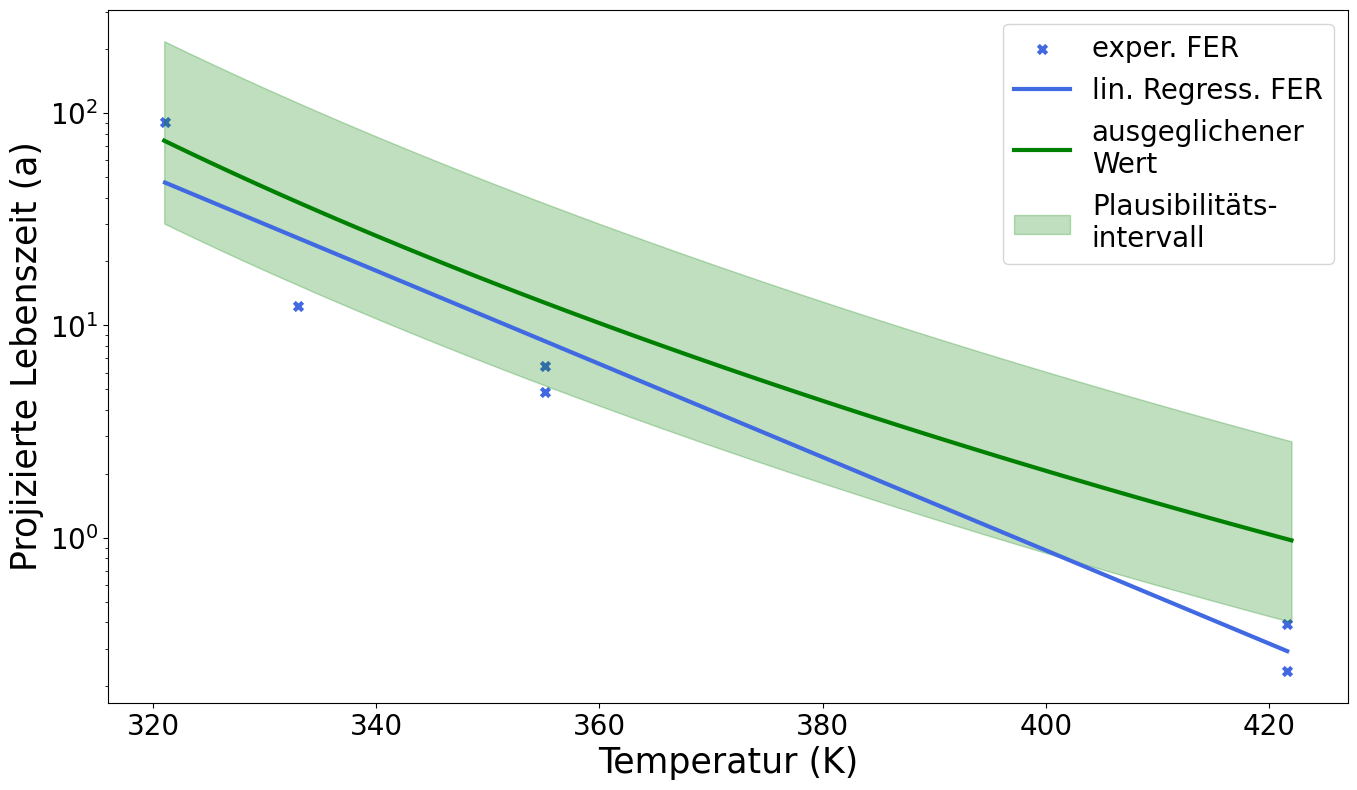

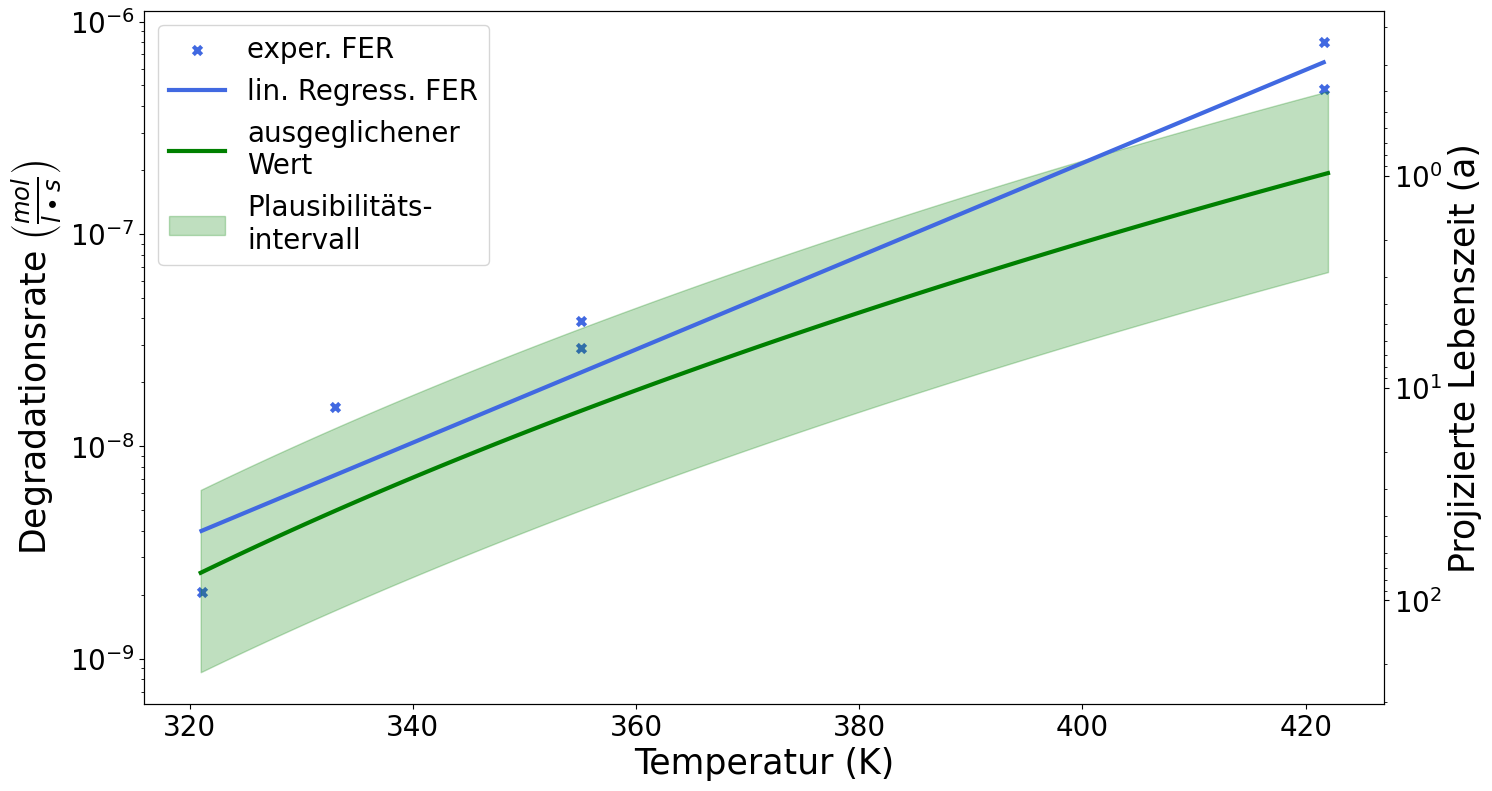

5.0840820000000004e-11
7.026780000000001e-12


In [14]:
plt.figure(figsize=(16,9))
plt.rc("lines", lw=3)
plt.rc("font", size=20)
plt.scatter(FER_data_L[0:6], FER_data_L[6:12], color="royalblue", label="exper. FER", marker="x")
plt.plot(FER_data_L[12:14], FER_data_L[14:16], color="royalblue", label="lin. Regress. FER")
plt.plot(1/T, attack_rate1, color="purple", label=r"1,6$\bullet$10$^{-5}$ $\frac{mol}{l\cdot s}$")#, 1.08 $\frac{A}{cm^2}$")
plt.plot(1/T, attack_rate2, color="green", label=r"1,6$\bullet$10$^{-6}$ $\frac{mol}{l\cdot s}$")#, 1.08 $\frac{A}{cm^2}$")
plt.plot(1/T, attack_rate3, color="red", label=r"1,6$\bullet$10$^{-7}$ $\frac{mol}{l\cdot s}$")#, 1.08 $\frac{A}{cm^2}$")
plt.plot(1/T, attack_rate4, color="orange", label=r"1,6$\bullet$10$^{-8}$ $\frac{mol}{l\cdot s}$")#, 1.08 $\frac{A}{cm^2}$")
# plt.plot(1/T, attack_rate5, color="darkorange", linestyle="dashed", label=r"~10$^{-8}$ $\frac{mol}{l\cdot s}$, 0.10 $\frac{A}{cm^2}$")
# plt.plot(1/T, attack_rate6, color="darkorange", linestyle="dotted", label=r"~10$^{-8}$ $\frac{mol}{l\cdot s}$, 2.00 $\frac{A}{cm^2}$")
plt.xlabel(r"Reziproke Temperatur $\left(\frac{1}{K}\right)$", fontsize=25)
plt.ylabel(r"Degradationsrate $\left(\frac{mol}{l \bullet s}\right)$", fontsize=25)
plt.legend(loc="lower left", fontsize=20)
plt.yscale("log")
plt.show()

#lifetime calculations
lifetime_FER=c_F*0.1/(FER_data_L[6:12]*3600*365*24)  #lifetime of FER in years
lifetime_FER_line=c_F*0.1/(FER_data_L[14:16]*3600*365*24)
lifetime2=c_F*0.1/(attack_rate2*3600*365*24)  #lifetime of attack_rate2 in years
lifetime_upper=c_F*0.1/(error_upper*3600*365*24)  #lifetime of error_upper in years
lifetime_lower=c_F*0.1/(error_lower*3600*365*24)  #lifetime of error_lower in years

plt.figure(figsize=(16,9))
plt.rc("lines", lw=3)
plt.rc("font", size=20)
plt.scatter(1/FER_data_L[0:6], lifetime_FER, color="royalblue", label="exper. FER", marker="x")
plt.plot(1/FER_data_L[12:14], lifetime_FER_line, color="royalblue", label="lin. Regress. FER")
plt.plot(T, lifetime2, linewidth=3, color="green", label="ausgeglichener\nWert")
# plt.plot(T, lifetime_upper, color="green", alpha=.5)
# plt.plot(T, lifetime_lower, color="green", alpha=.5)
plt.fill_between(T, lifetime_upper, lifetime_lower, color="green", alpha=.25, label="Plausibilitäts-\nintervall")
# plt.xlabel("temperature (K)", fontsize=25)
# plt.ylabel("projected lifetime (h)", fontsize=25)
plt.xlabel("Temperatur (K)", fontsize=25)
plt.ylabel("Projizierte Lebenszeit (a)", fontsize=25)
plt.yscale("log")
plt.legend()
plt.show()

plt.rc("lines", lw=3)
plt.rc("font", size=20)
fig, ax1=plt.subplots(figsize=(16,9))
ax1.scatter(1/FER_data_L[0:6], FER_data_L[6:12], color="royalblue", label="exper. FER", marker="x")
ax1.plot(1/FER_data_L[12:14], FER_data_L[14:16], color="royalblue", label="lin. Regress. FER")
ax1.plot(T, attack_rate2, color="green", label="ausgeglichener\nWert")
ax1.fill_between(T, error_lower, error_upper, color="green", label="Plausibilitäts-\nintervall", alpha=.25)
plt.yscale("log")
plt.ylabel(r"Degradationsrate $\left(\frac{mol}{l \bullet s}\right)$", fontsize=25)
plt.xlabel("Temperatur (K)", fontsize=25)
plt.legend()
ax2=ax1.twinx()
ax2.scatter(1/FER_data_L[0:6], lifetime_FER, color="royalblue", marker="x", alpha=0)
ax2.plot(1/FER_data_L[12:14], lifetime_FER_line, color="royalblue", alpha=0)
ax2.plot(T, lifetime2, color="green", alpha=0)
ax2.fill_between(T, lifetime_lower, lifetime_upper, color="green", alpha=0)
plt.gca().invert_yaxis()
plt.yscale("log")
plt.ylabel("Projizierte Lebenszeit (a)", fontsize=25)
plt.show()
print(2.46*2.0667e-11)
print(0.34*2.0667e-11)

In [10]:
#temperature dependance, comparing cuppled and separate
#parameters
T=np.linspace(321,422,100)  #temperature in K
P_cat=6.7e5                 #cathode pressure in Pa
P_an=6.7e5                  #anode pressure in Pa
h_memb=183e-6               #membrane thickness in m
h_cat=10e-6                 #cathode thickness in m
h_an=10e-6                  #anode thickness in m

c_COOH=1.17                                  #concentration of COOH-endgroups in mol/l
c_Fe2=7.0E-8                                 #starting concentration of Fe2+ ions in mol/l
c_Fe3=7.0E-8                                 #starting concentration of Fe3+ ions in mol/l
c_proton=(1980+32.4*16)/(1+0.00648*16)/1000  #proton concentration in the ionomer in mol/l

#function execution
# 1. creating a list for each set of parameters
attack_rate1=[]
attack_rate2=[]
attack_rate3=[]
# 2. running the function deg_rate() with each set of parameters; the function only takes single values not lists or arrays, therefore this loop
i=0
while i<len(T):
    cuppled=True
    attack_rate1.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e-2,1)[2])
    cuppled=False
    attack_rate2.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e-2,1)[0])
    attack_rate3.append(deg_rate(T[i],10800,P_cat,P_an,h_memb,1e-2,1)[1])
    clear_output(wait=True)
    print(i)
    i+=1
# 3. converting the lists to np.arrays for better handling
attack_rate1=np.array(attack_rate1)
attack_rate2=np.array(attack_rate2)
attack_rate3=np.array(attack_rate3)

99


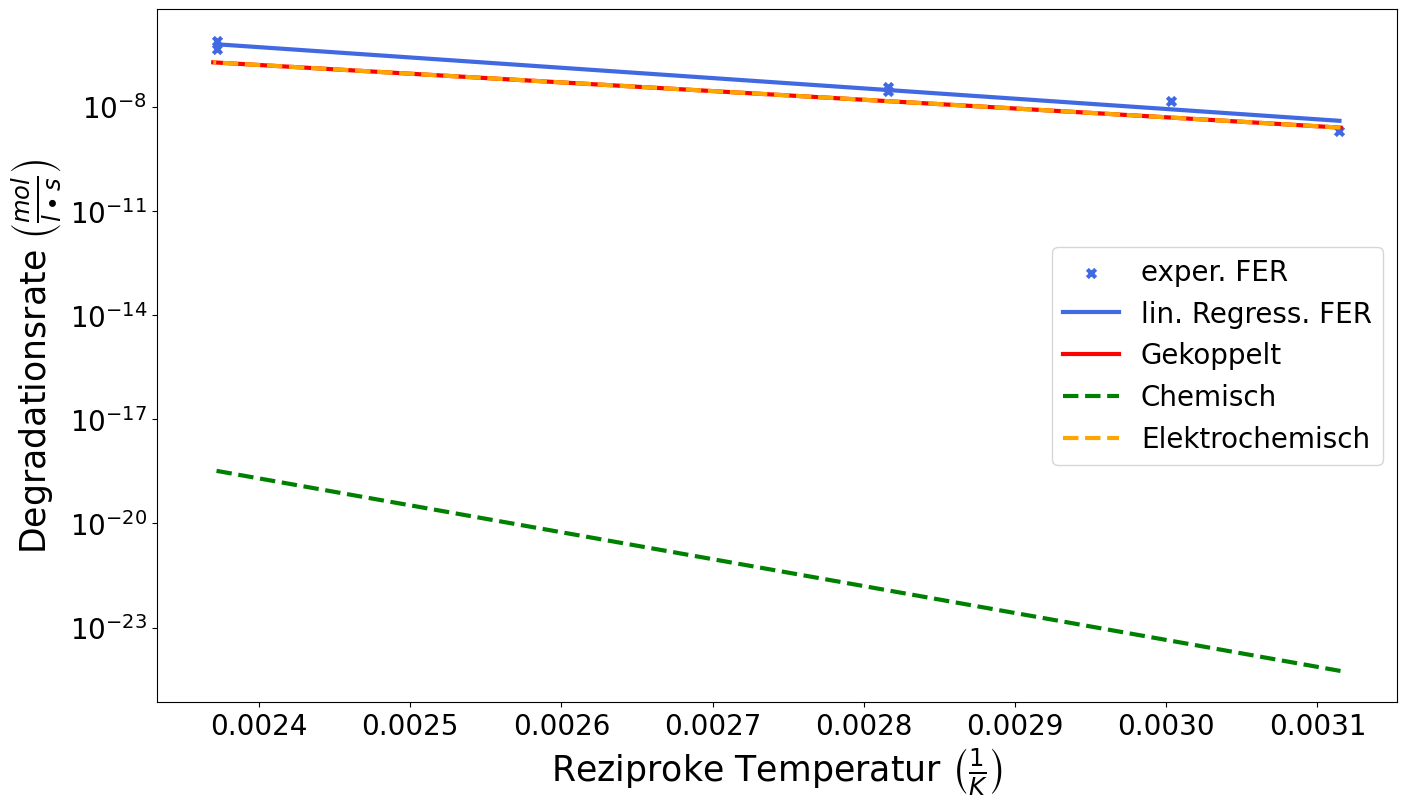

In [9]:
plt.figure(figsize=(16,9))
plt.rc("lines", lw=3)
plt.rc("font", size=20)
plt.scatter(FER_data_L[0:6], FER_data_L[6:12], color="royalblue", label="exper. FER", marker="x")
plt.plot(FER_data_L[12:14], FER_data_L[14:16], color="royalblue", label="lin. Regress. FER")
plt.plot(1/T, attack_rate1, color="red", label="Gekoppelt")
plt.plot(1/T, attack_rate2, color="green", label="Chemisch", linestyle="dashed")
plt.plot(1/T, attack_rate3, color="orange", label="Elektrochemisch", linestyle="dashed")
plt.ylabel(r"Degradationsrate $\left(\frac{mol}{l \bullet s}\right)$", fontsize=25)
plt.xlabel(r"Reziproke Temperatur $\left(\frac{1}{K}\right)$", fontsize=25)
plt.yscale("log")
plt.legend()
plt.show()

In [28]:
#current density dependance for lifetime and production
#parameters
cuppled=True
T=273.15+80
curden=np.linspace(0,30000,100)
curden[0]=curden[1]
P_cat=10e5
P_an=10e5
h_memb=183e-6
h_cat=10e-6
h_an=10e-6
f_Fe=1e0

c_COOH=1.17  #concentration of COOH-endgroups in mol/l
c_Fe2=7.0E-8  #starting concentration of Fe2+ ions in mol/l
c_Fe3=7.0E-8  #starting concentration of Fe3+ ions in mol/l
c_proton=(1980+32.4*16)/(1+0.00648*16)/1000  #proton concentration in the ionomer in mol/l

#function execution
# 1. creating a list for each set of parameters
attack_rate1=[]
attack_rate2=[]
attack_rate3=[]
# 2. running the function deg_rate() with each set of parameters; the function only takes single values not lists or arrays, therefore this loop
i=0
while i<len(curden):
    attack_rate1.append(deg_rate(T,curden[i],P_cat,P_an,h_memb,f_Fe,1)[2])
    attack_rate2.append(deg_rate(T,curden[i],P_cat,P_an,h_memb,f_Fe,2.46)[2])
    attack_rate3.append(deg_rate(T,curden[i],P_cat,P_an,h_memb,f_Fe,0.34)[2])
    clear_output(wait=True)
    print(i)
    i+=1
# 3. converting the lists to np.arrays for better handling
attack_rate1=np.array(attack_rate1)
attack_rate2=np.array(attack_rate2)
attack_rate3=np.array(attack_rate3)

99


9.25 12424.242424242424


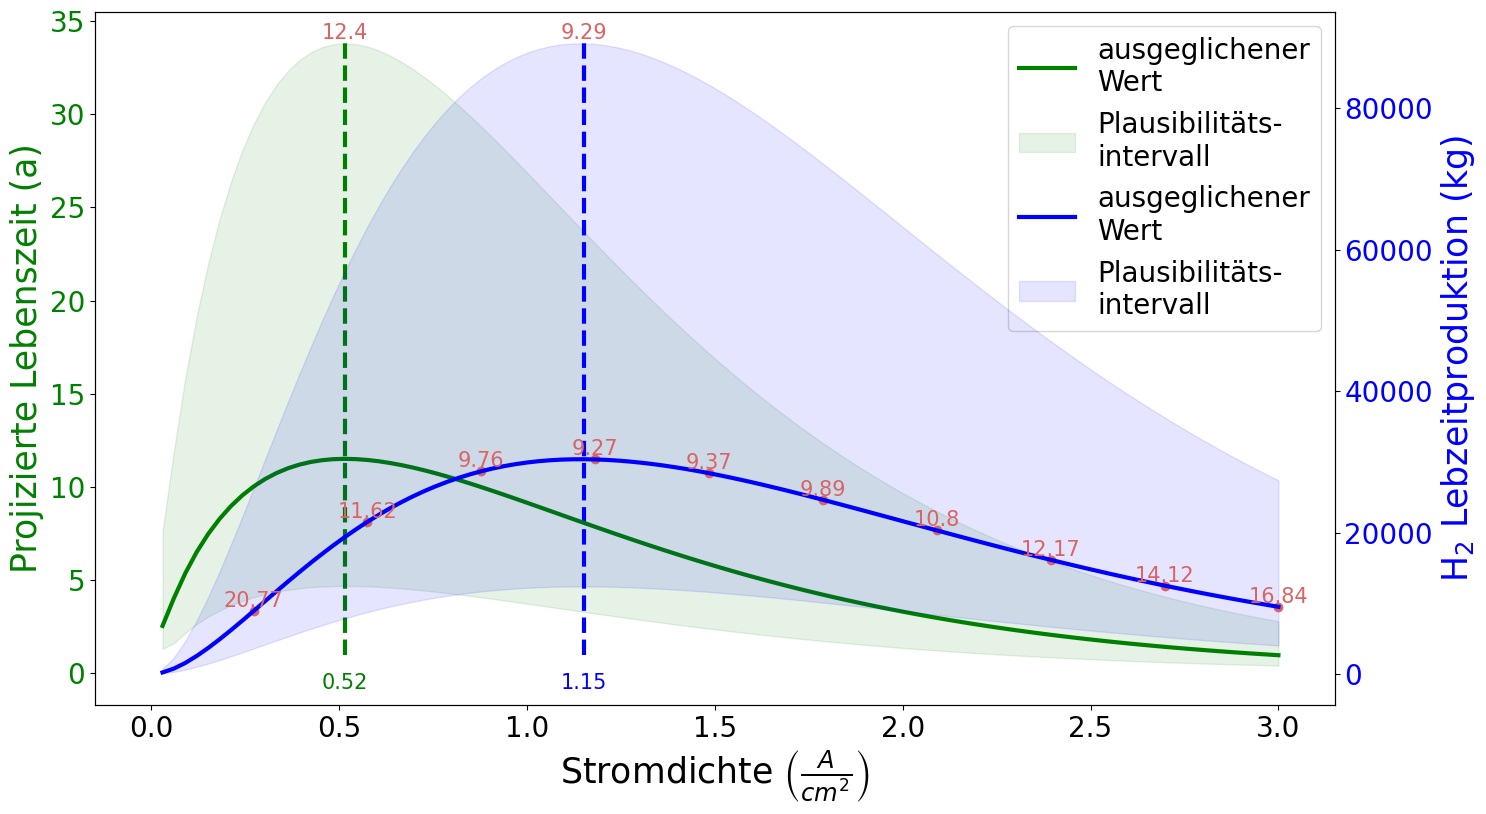

In [32]:
A=1  #active membrane area in m²
energy_price=0.1/1000  #in €/Wh

lifetime1=0.1*c_F/(attack_rate1*3600*24*365)  #lifetime in a
lifetime2=0.1*c_F/(attack_rate2*3600*24*365)
lifetime3=0.1*c_F/(attack_rate3*3600*24*365)

life_prod1=curden*lifetime1*3600*24*365*M_H2*A/(2*F)  #lifetime H2 production in kg
life_prod2=curden*lifetime2*3600*24*365*M_H2*A/(2*F)
life_prod3=curden*lifetime3*3600*24*365*M_H2*A/(2*F)

curden_points=curden[[9,19,29,39,49,59,69,79,89,99]]  #points to display price at
lifetime_points=lifetime1[[9,19,29,39,49,59,69,79,89,99]]
life_prod_points=life_prod1[[9,19,29,39,49,59,69,79,89,99]]

test=[]
i=0
while i<len(curden):
    test.append(round(H2_price(T,curden[i],P_cat,P_an,h_memb,A,lifetime1[i]*24*365,energy_price)[0],2))
    i+=1
print(min(test), curden[test.index(min(test))])

lifetime1=list(lifetime1)
life_prod1=list(life_prod1)
fig, ax1=plt.subplots(figsize=(16,9))
plt.rc("lines", lw=3)
plt.rc("font", size=20)
plt.vlines(curden[lifetime1.index(max(lifetime1))]/1e4,1,max(lifetime3),color="green", linestyle="dashed")
plt.text(curden[lifetime1.index(max(lifetime1))]/1e4,0,round(curden[lifetime1.index(max(lifetime1))]/1e4,2),color="green",va="top",ha="center",fontsize=15)
plt.text(curden[lifetime1.index(max(lifetime1))]/1e4,max(lifetime3),round(H2_price(T,curden[lifetime1.index(max(lifetime1))],P_cat,P_an,h_memb,A,max(lifetime1)*24*365,energy_price)[0],2),color="#DA6363",va="bottom",ha="center",fontsize=15)
plt.vlines(curden[life_prod1.index(max(life_prod1))]/1e4,1,max(lifetime3),color="blue", linestyle="dashed")
plt.text(curden[life_prod1.index(max(life_prod1))]/1e4,0,round(curden[life_prod1.index(max(life_prod1))]/1e4,2),color="blue",va="top",ha="center",fontsize=15)
plt.text(curden[life_prod1.index(max(life_prod1))]/1e4,max(lifetime3),round(H2_price(T,curden[life_prod1.index(max(life_prod1))],P_cat,P_an,h_memb,A,lifetime1[life_prod1.index(max(life_prod1))]*24*365,energy_price)[0],2),color="#DA6363",va="bottom",ha="center",fontsize=15)
plt.plot(curden/1e4, lifetime1, label="ausgeglichener\nWert", color="green")
plt.fill_between(curden/1e4, lifetime1, lifetime2, color="green", alpha=.1, label="Plausibilitäts-\nintervall")
plt.fill_between(curden/1e4, lifetime1, lifetime3, color="green", alpha=.1)
plt.plot(0,0,color="blue", label="ausgeglichener\nWert")
plt.fill_between([0,0],0,0,color="blue",alpha=.1,label="Plausibilitäts-\nintervall")
plt.xlabel(r"Stromdichte $\left(\frac{A}{cm^2}\right)$", fontsize=25)
plt.ylabel("Projizierte Lebenszeit (a)", fontsize=25, color="green")
plt.legend(loc="upper right")
plt.yticks(color="green")
ax2=ax1.twinx()
ax2.plot(curden/1e4, life_prod1, color="blue",)
ax2.fill_between(curden/1e4, life_prod1, life_prod2, alpha=.1, color="blue")
ax2.fill_between(curden/1e4, life_prod1, life_prod3, alpha=.1, color="blue")
ax2.scatter(curden_points/1e4,life_prod_points,color="#DA6363")
i=0
while i<len(curden_points):
    plt.text(curden_points[i]/1e4,life_prod_points[i],round(H2_price(T,curden_points[i],P_cat,P_an,h_memb,A,lifetime_points[i]*24*365,energy_price)[0],2),color="#DA6363",va="bottom",ha="center",fontsize=15)
    i+=1
ax2.set_ylabel("H$_2$ Lebzeitproduktion (kg)", color="blue", fontsize=25)
plt.yticks(color="blue")
plt.show()

99


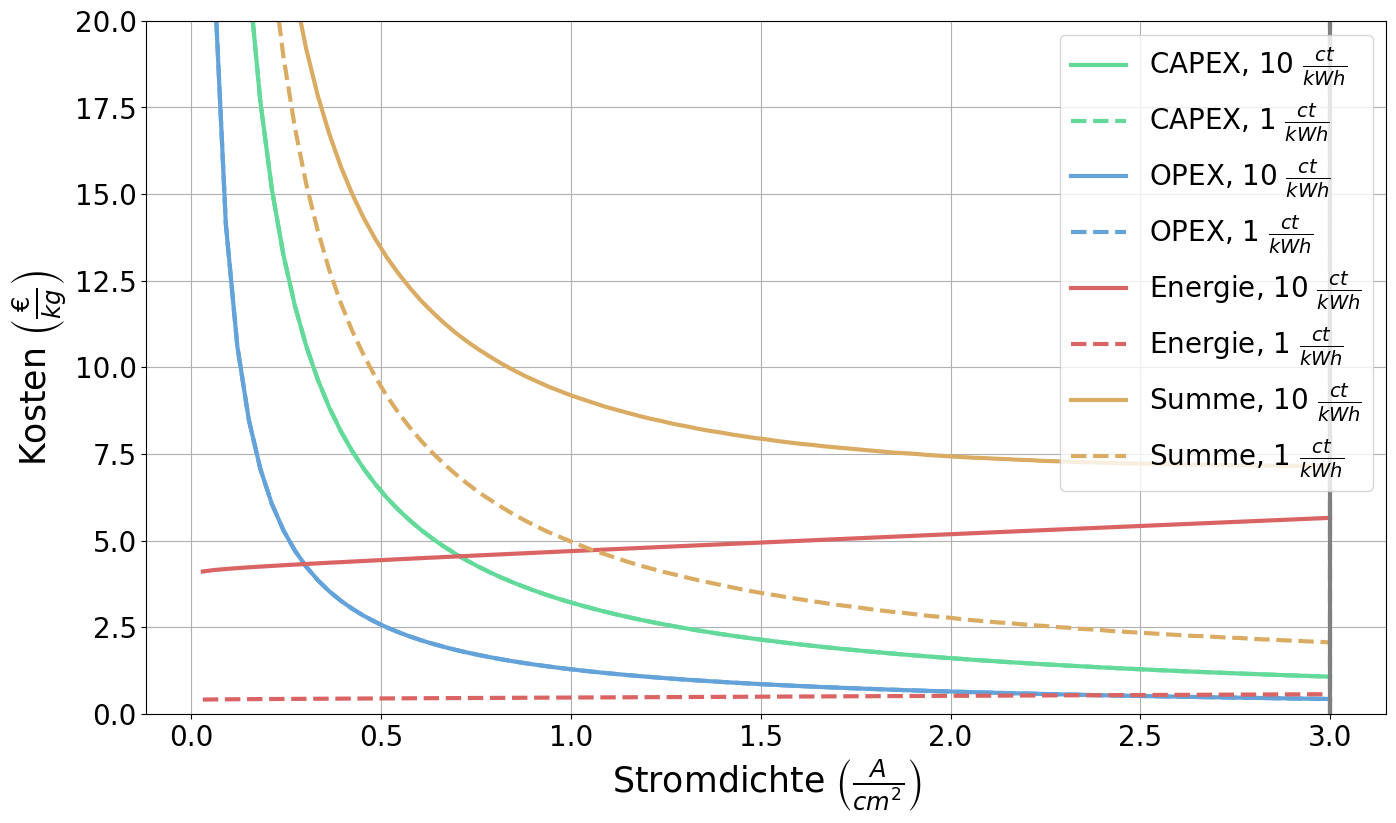

In [35]:
#price test
T=273.15+80
curden=np.linspace(0,30000,100)
curden[0]=curden[1]
P_cat=10e5
P_an=10e5
h_memb=183e-6
A=1

sigma=1.5
mu=.5
#lifetime=10*np.exp(-0.5*((curden/1e4-mu)/sigma)**2)/(sigma*np.sqrt(2*np.pi))
lifetime=np.linspace(10,10,100)
price_a=np.array([])
life_prod_a=np.array([])
CAPEX_a=np.array([])
OPEX_a=np.array([])
energy_a=np.array([])
price_b=np.array([])
life_prod_b=np.array([])
CAPEX_b=np.array([])
OPEX_b=np.array([])
energy_b=np.array([])
i=0
while i<len(curden):
    price_a=np.append(price_a,round(H2_price(T,curden[i],P_cat,P_an,h_memb,A,lifetime[i]*365*24,0.1/1000)[0],2))
    life_prod_a=np.append(life_prod_a,round(H2_price(T,curden[i],P_cat,P_an,h_memb,A,lifetime[i]*365*24,0.1/1000)[1]))
    CAPEX_a=np.append(CAPEX_a,round(H2_price(T,curden[i],P_cat,P_an,h_memb,A,lifetime[i]*365*24,0.1/1000)[2],2))
    OPEX_a=np.append(OPEX_a,round(H2_price(T,curden[i],P_cat,P_an,h_memb,A,lifetime[i]*365*24,0.1/1000)[3],2))
    energy_a=np.append(energy_a,round(H2_price(T,curden[i],P_cat,P_an,h_memb,A,lifetime[i]*365*24,0.1/1000)[4],2))
    
    price_b=np.append(price_b,round(H2_price(T,curden[i],P_cat,P_an,h_memb,A,lifetime[i]*365*24,0.01/1000)[0],2))
    life_prod_b=np.append(life_prod_b,round(H2_price(T,curden[i],P_cat,P_an,h_memb,A,lifetime[i]*365*24,0.01/1000)[1]))
    CAPEX_b=np.append(CAPEX_b,round(H2_price(T,curden[i],P_cat,P_an,h_memb,A,lifetime[i]*365*24,0.01/1000)[2],2))
    OPEX_b=np.append(OPEX_b,round(H2_price(T,curden[i],P_cat,P_an,h_memb,A,lifetime[i]*365*24,0.01/1000)[3],2))
    energy_b=np.append(energy_b,round(H2_price(T,curden[i],P_cat,P_an,h_memb,A,lifetime[i]*365*24,0.01/1000)[4],2))
    
    clear_output(wait=True)
    print(i)
    i+=1

price_a=list(price_a)
price_b=list(price_b)
plt.figure(figsize=(16,9))
plt.rc("lines", lw=3)
plt.rc("font", size=20)
# plt.plot(curden/1e4,price_test)
plt.plot(curden/1e4,CAPEX_a/life_prod_a, label=r"CAPEX, 10 $\frac{ct}{kWh}$",color="#63DA9A")
plt.plot(curden/1e4,CAPEX_b/life_prod_b, label=r"CAPEX, 1 $\frac{ct}{kWh}$", color="#63DA9A", ls="dashed")
plt.plot(curden/1e4,OPEX_a/life_prod_a, label=r"OPEX, 10 $\frac{ct}{kWh}$",color="#63A3DA")
plt.plot(curden/1e4,OPEX_b/life_prod_b, label=r"OPEX, 1 $\frac{ct}{kWh}$", color="#63A3DA", ls="dashed")
plt.plot(curden/1e4,energy_a/life_prod_a, label=r"Energie, 10 $\frac{ct}{kWh}$",color="#DA6363")
plt.plot(curden/1e4,energy_b/life_prod_b, label=r"Energie, 1 $\frac{ct}{kWh}$", color="#DA6363", ls="dashed")
plt.plot(curden/1e4,price_a, label=r"Summe, 10 $\frac{ct}{kWh}$",color="#DAAC63")
plt.plot(curden/1e4,price_b, label=r"Summe, 1 $\frac{ct}{kWh}$", color="#DAAC63", ls="dashed")
plt.xlabel(r"Stromdichte $\left(\frac{A}{cm^2}\right)$", fontsize=25)
plt.vlines(curden[price_a.index(min(price_a))]/1e4,0,20, color="grey")
plt.vlines(curden[price_b.index(min(price_b))]/1e4,0,20, color="grey", ls="dashed")
plt.ylabel(r"Kosten $\left(\frac{€}{kg}\right)$", fontsize=25)
plt.ylim(0,20)
plt.legend(loc="upper right")
plt.grid()
plt.show()

In [34]:
#current density dependance, comparison with Chandesris
#parameters
cuppled=True
curden=np.linspace(0,16000,100)
curden[0]=curden[1]
P_cat=50e5
P_an=50e5
h_memb=183e-6
h_cat=10e-6
h_an=10e-6
f_Fe=1e0

c_COOH=1.17  #concentration of COOH-endgroups in mol/l
c_Fe2=7.0E-8  #starting concentration of Fe2+ ions in mol/l
c_Fe3=7.0E-8  #starting concentration of Fe3+ ions in mol/l
c_proton=(1980+32.4*16)/(1+0.00648*16)/1000  #proton concentration in the ionomer in mol/l

#function execution
# 1. creating a list for each set of parameters
attack_rate1=[]
attack_rate2=[]
attack_rate3=[]
attack_rate4=[]
# 2. running the function deg_rate() with each set of parameters; the function only takes single values not lists or arrays, therefore this loop
i=0
while i<len(curden):
    attack_rate1.append(deg_rate(273.15+60,curden[i],P_cat,P_an,h_memb,f_Fe,1)[2])
    attack_rate2.append(deg_rate(273.15+80,curden[i],P_cat,P_an,h_memb,f_Fe,1)[2])
    attack_rate3.append(deg_rate(273.15+60,curden[i],P_cat,P_an,h_memb,f_Fe,2.46)[2])
    attack_rate4.append(deg_rate(273.15+80,curden[i],P_cat,P_an,h_memb,f_Fe,2.46)[2])
    clear_output(wait=True)
    print(i)
    i+=1
# 3. converting the lists to np.arrays for better handling
attack_rate1=np.array(attack_rate1)
attack_rate2=np.array(attack_rate2)
attack_rate3=np.array(attack_rate3)
attack_rate4=np.array(attack_rate4)

99


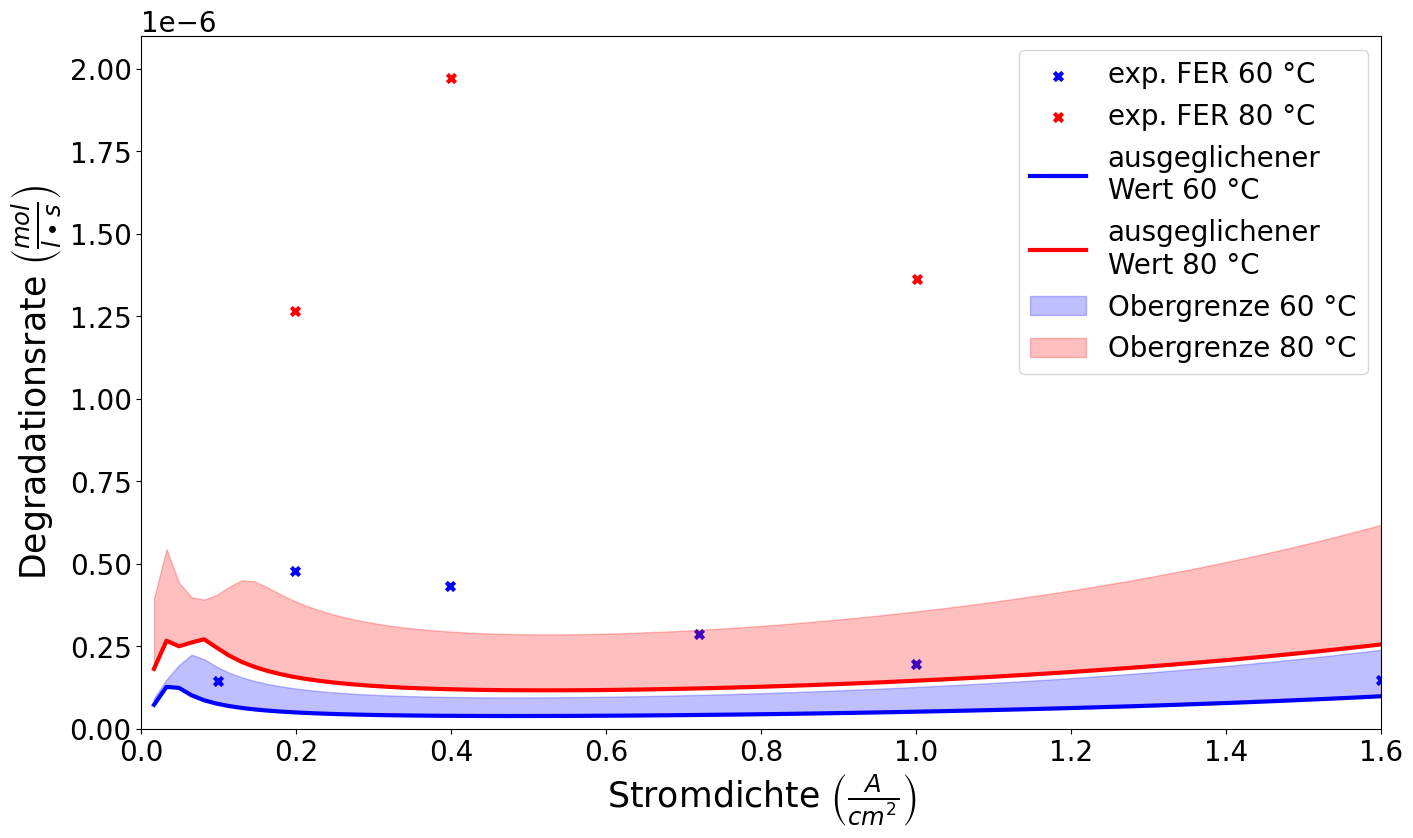

In [35]:
plt.figure(figsize=(16,9))
plt.rc("lines", lw=3)
plt.rc("font", size=20)
plt.scatter(FER_data_C[0:6],FER_data_C[6:12], color="blue", label="exp. FER 60 °C", marker="x")
plt.scatter(FER_data_C[12:15],FER_data_C[15:18], color="red", label="exp. FER 80 °C", marker="x")
plt.plot(curden*1e-4,attack_rate1, color="blue", label="ausgeglichener\nWert 60 °C")
plt.plot(curden*1e-4,attack_rate2, color="red", label="ausgeglichener\nWert 80 °C")
plt.fill_between(curden*1e-4, attack_rate1, attack_rate3, color="blue", label="Obergrenze 60 °C", alpha=.25)
plt.fill_between(curden*1e-4, attack_rate2, attack_rate4, color="red", label="Obergrenze 80 °C", alpha=.25)
plt.xlabel(r"Stromdichte $\left(\frac{A}{cm^2}\right)$", fontsize=25)
plt.ylabel(r"Degradationsrate $\left(\frac{mol}{l \bullet s}\right)$", fontsize=25)
plt.xlim(0,1.6)
plt.ylim(0,2.1e-6)
plt.legend(loc="upper right")
# plt.yscale("log")
plt.show()

In [15]:
#current density dependance
#parameters
cuppled=True
T=273.15+60
curden=np.linspace(0,30000,100)
curden[0]=curden[1]
h_cat=10e-6
h_an=10e-6
f_Fe=1e0
pre_k9=1

c_COOH=1.17  #concentration of COOH-endgroups in mol/l
c_Fe2=7.0E-8  #starting concentration of Fe2+ ions in mol/l
c_Fe3=7.0E-8  #starting concentration of Fe3+ ions in mol/l
c_proton=(1980+32.4*16)/(1+0.00648*16)/1000  #proton concentration in the ionomer in mol/l

#function execution
# 1. creating a list for each set of parameters
attack_rate1=[]
attack_rate2=[]
attack_rate3=[]
attack_rate4=[]
attack_rate5=[]
attack_rate6=[]
attack_rate7=[]
attack_rate8=[]
# 2. running the function deg_rate() with each set of parameters; the function only takes single values not lists or arrays, therefore this loop
i=0
while i<len(curden):
    attack_rate1.append(deg_rate(273.15+60,curden[i],10e5,10e5,183e-6,f_Fe,pre_k9)[2])
    attack_rate2.append(deg_rate(273.15+60,curden[i],15e5,10e5,183e-6,f_Fe,pre_k9)[2])
    attack_rate3.append(deg_rate(273.15+60,curden[i],10e5,10e5,50.8e-6,f_Fe,pre_k9)[2])
    attack_rate4.append(deg_rate(273.15+60,curden[i],15e5,10e5,50.8e-6,f_Fe,pre_k9)[2])
    attack_rate5.append(deg_rate(273.15+80,curden[i],10e5,10e5,183e-6,f_Fe,pre_k9)[2])
    attack_rate6.append(deg_rate(273.15+80,curden[i],15e5,10e5,183e-6,f_Fe,pre_k9)[2])
    attack_rate7.append(deg_rate(273.15+80,curden[i],10e5,10e5,50.8e-6,f_Fe,pre_k9)[2])
    attack_rate8.append(deg_rate(273.15+80,curden[i],15e5,10e5,50.8e-6,f_Fe,pre_k9)[2])
    clear_output(wait=True)
    print(i)
    i+=1
# 3. converting the lists to np.arrays for better handling
attack_rate1=np.array(attack_rate1)
attack_rate2=np.array(attack_rate2)
attack_rate3=np.array(attack_rate3)
attack_rate4=np.array(attack_rate4)
attack_rate5=np.array(attack_rate5)
attack_rate6=np.array(attack_rate6)
attack_rate7=np.array(attack_rate7)
attack_rate8=np.array(attack_rate8)

99


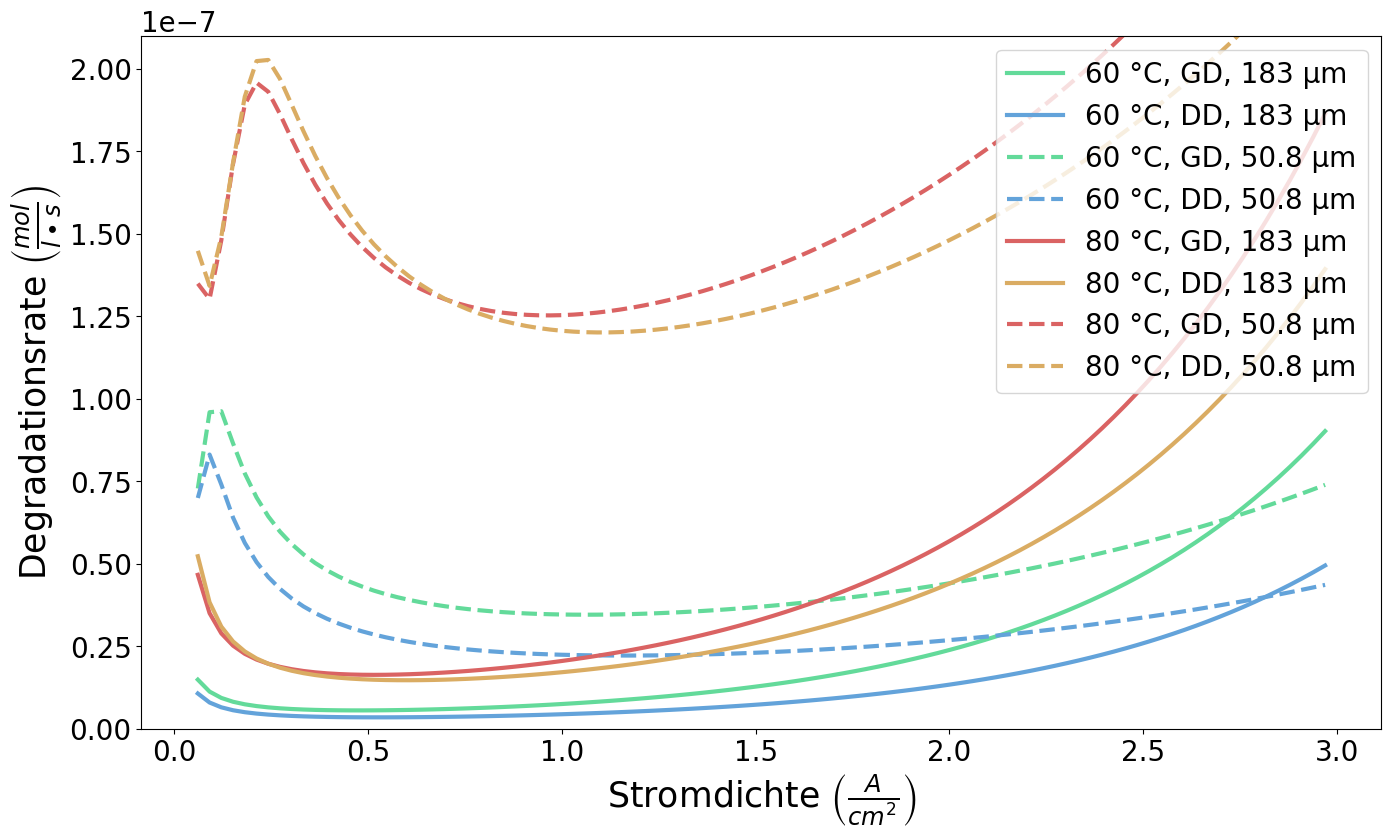

In [16]:
start=2
plt.figure(figsize=(16,9))
plt.rc("lines", lw=3)
plt.rc("font", size=20)
plt.plot(curden[start:-1]*1e-4,attack_rate1[start:-1], color="#63DA9A", label="60 °C, GD, 183 µm")
plt.plot(curden[start:-1]*1e-4,attack_rate2[start:-1], color="#63A3DA", label="60 °C, DD, 183 µm")
plt.plot(curden[start:-1]*1e-4,attack_rate3[start:-1], color="#63DA9A", label="60 °C, GD, 50.8 µm", ls="dashed")
plt.plot(curden[start:-1]*1e-4,attack_rate4[start:-1], color="#63A3DA", label="60 °C, DD, 50.8 µm", ls="dashed")
plt.plot(curden[start:-1]*1e-4,attack_rate5[start:-1], color="#DA6363", label="80 °C, GD, 183 µm")
plt.plot(curden[start:-1]*1e-4,attack_rate6[start:-1], color="#DAAC63", label="80 °C, DD, 183 µm")
plt.plot(curden[start:-1]*1e-4,attack_rate7[start:-1], color="#DA6363", label="80 °C, GD, 50.8 µm", ls="dashed")
plt.plot(curden[start:-1]*1e-4,attack_rate8[start:-1], color="#DAAC63", label="80 °C, DD, 50.8 µm", ls="dashed")
plt.xlabel(r"Stromdichte $\left(\frac{A}{cm^2}\right)$", fontsize=25)
plt.ylabel(r"Degradationsrate $\left(\frac{mol}{l \bullet s}\right)$", fontsize=25)
plt.legend(loc="upper right")
plt.ylim(0,2.1e-7)
plt.show()

In [7]:
#iron source term dependance
#parameters
cuppled=True
T=273.15+60
curden=10800
P_cat=6.7e5
P_an=6.7e5
h_memb=183e-6
h_cat=10e-6
h_an=10e-6
f_Fe=np.logspace(-4,1.9,50)
pre_k9=1

c_COOH=1.17  #concentration of COOH-endgroups in mol/l
c_Fe2=7.0E-8  #starting concentration of Fe2+ ions in mol/l
c_Fe3=7.0E-8  #starting concentration of Fe3+ ions in mol/l
c_proton=(1980+32.4*16)/(1+0.00648*16)/1000  #proton concentration in the ionomer in mol/l

#function execution
# 1. creating a list for each set of parameters
conc=[]
rates=[]
# 2. running the function deg_rate() with each set of parameters; the function only takes single values not lists or arrays, therefore this loop
i=0
while i<len(f_Fe):
    conc.append(deg_rate(T,curden,P_cat,P_an,h_memb,f_Fe[i],pre_k9)[3])
    rates.append(deg_rate(T,curden,P_cat,P_an,h_memb,f_Fe[i],pre_k9)[4])
    clear_output(wait=True)
    print(i)
    i+=1
# 3. converting the lists to np.arrays for better handling
conc=np.array(conc)
rates=np.array(rates)

49


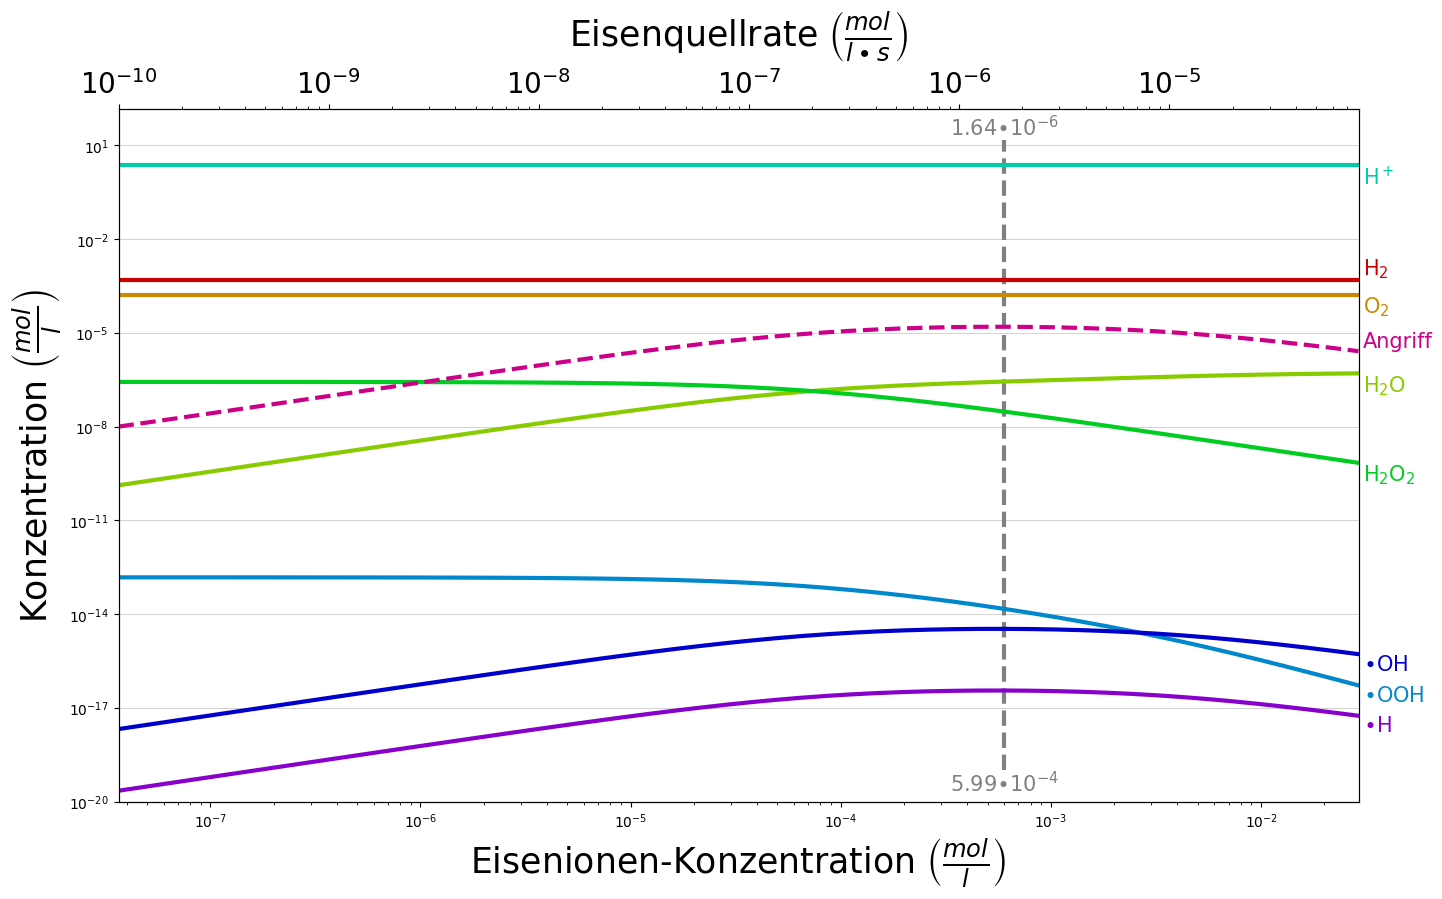

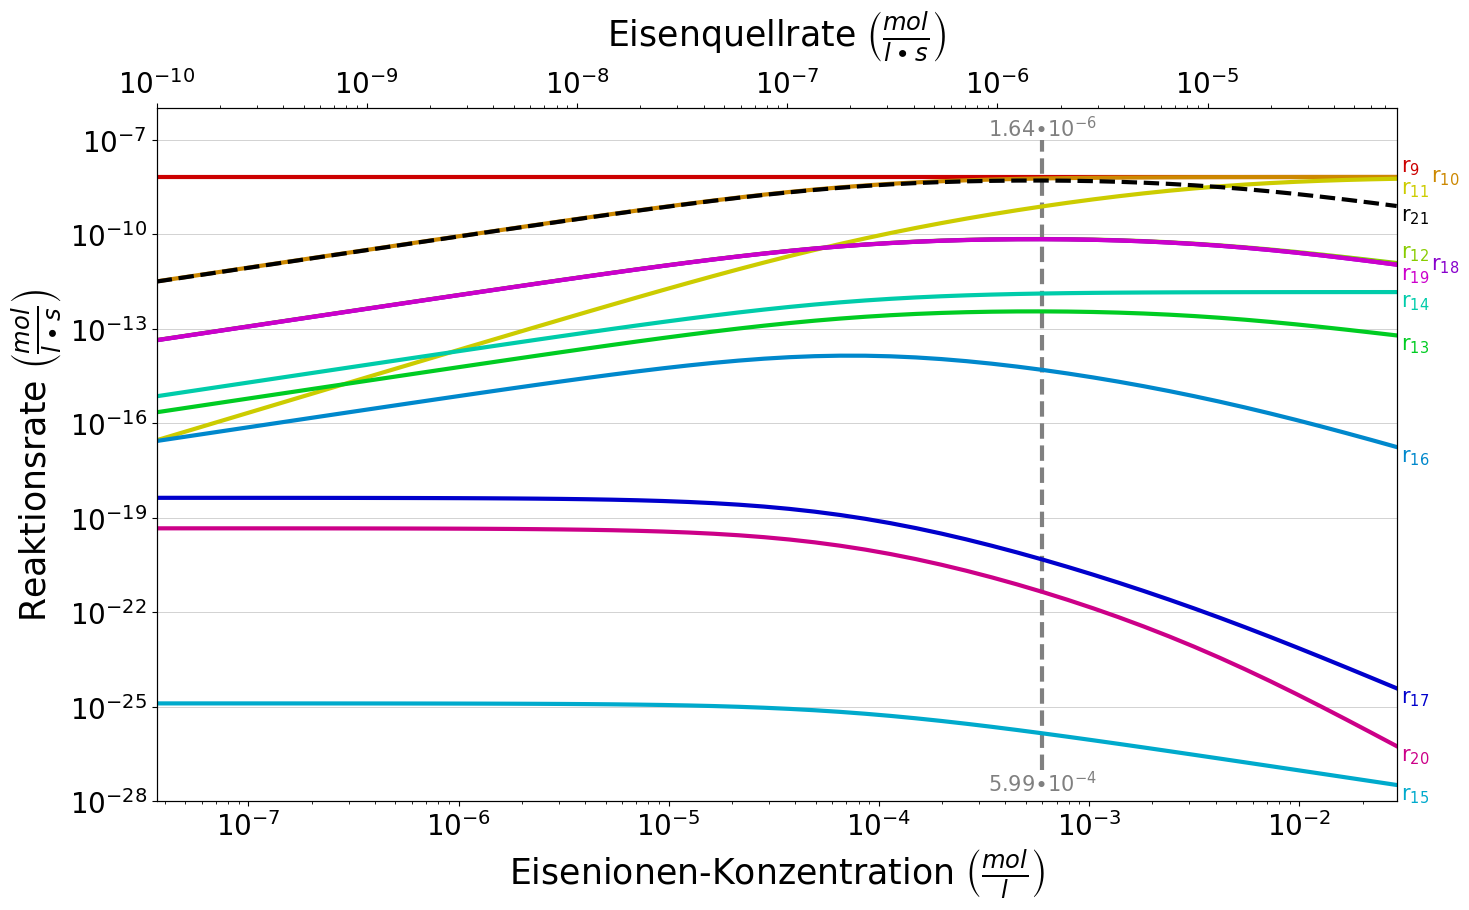

In [8]:
specie=["H$_2$","O$_2$","H$_2$O","H$_2$O$_2$","Fe$^{2+}$","Fe$^{3+}$","H$^+$",r"$\bullet$OOH",r"$\bullet$OH",r"$\bullet$H","Angriff"]
color=["#cc0000","#cc8800","#88cc00","#00cc22","#000000","#000000","#00ccaa","#0088cc","#0000cc","#8800cc","#cc0088"]
reaction=["r$_9$","r$_{10}$","r$_{11}$","r$_{12}$","r$_{13}$","r$_{14}$","r$_{15}$","r$_{16}$","r$_{17}$","r$_{18}$","r$_{19}$","r$_{20}$","r$_{21}$",]
color_r=["#cc0000","#cc8800","#cccc00","#88cc00","#00cc22","#00ccaa","#00aacc","#0088cc","#0000cc","#8800cc","#cc00cc","#cc0088","#000000"]
attacks=list(conc[:,17])
attacks_r=list(rates[:,12])

fig, ax1=plt.subplots(figsize=(16,9))
plt.rc("lines", lw=3)
plt.rc("font", size=20)
plt.vlines(conc[attacks.index(max(attacks)),11]+conc[attacks.index(max(attacks)),12],1e-19,1.5e1,linestyle="dashed", color="grey")
plt.text(conc[attacks.index(max(attacks)),11]+conc[attacks.index(max(attacks)),12],1e-19,str(round((conc[attacks.index(max(attacks)),11]+conc[attacks.index(max(attacks)),12])*1e4,2))+r"$\bullet$10$^{-4}$",color="grey",fontsize=15,ha="center",va="top")
plt.text(conc[attacks.index(max(attacks)),11]+conc[attacks.index(max(attacks)),12],1.5e1,str(round(f_Fe[attacks.index(max(attacks))],2))+r"$\bullet$10$^{-6}$",color="grey",fontsize=15,ha="center",va="bottom")
i=7
while i<18:
    if i!=11 and i!=12 and i!=7 and i!=17:  #all but Fe-Ions, H_2 and attacks
        ax1.plot(conc[:,11]+conc[:,12], conc[:,i], label=specie[i-7], color=color[i-7])
        plt.text(1.1*conc[-1,11]+conc[-1,12], conc[-1,i], specie[i-7],color=color[i-7], va="top", fontsize=15)
    elif i!=11 and i!=12 and i!=17:  #all but Fe-Ions and attacks
        ax1.plot(conc[:,11]+conc[:,12], conc[:,i], label=specie[i-7], color=color[i-7])
        plt.text(1.1*conc[-1,11]+conc[-1,12], conc[-1,i], specie[i-7],color=color[i-7], va="bottom", fontsize=15)
    elif i!=11 and i!=12:  #all but Fe-Ions
        ax1.plot(conc[:,11]+conc[:,12], conc[:,i], label=specie[i-7], color=color[i-7], linestyle="dashed")
        plt.text(1.1*conc[-1,11]+conc[-1,12], conc[-1,i], specie[i-7],color=color[i-7], va="bottom", fontsize=15)
    i+=1
plt.xscale("log")
plt.yscale("log")
plt.xlim(conc[0,11]+conc[0,12],conc[-1,11]+conc[-1,12])
plt.ylim(1e-20,1.5e2)
plt.xlabel(r"Eisenionen-Konzentration $\left(\frac{mol}{l}\right)$", fontsize=25)
plt.ylabel(r"Konzentration $\left(\frac{mol}{l}\right)$", fontsize=25)
plt.grid(axis="y", lw=.4)
ax2=ax1.twiny()
ax2.set_xlim(f_Fe[0]*1e-6,f_Fe[-1]*1e-6)
ax2.set_xscale("log")
ax2.set_xlabel(r"Eisenquellrate $\left(\frac{mol}{l\bullet s}\right)$", fontsize=25, va="bottom")
plt.show()


fig, ax1=plt.subplots(figsize=(16,9))
plt.rc("lines", lw=3)
plt.rc("font", size=20)
plt.vlines(conc[attacks_r.index(max(attacks_r)),11]+conc[attacks_r.index(max(attacks_r)),12],1e-27,1e-7,linestyle="dashed", color="grey")
plt.text(conc[attacks_r.index(max(attacks_r)),11]+conc[attacks_r.index(max(attacks_r)),12],1e-27,str(round((conc[attacks_r.index(max(attacks_r)),11]+conc[attacks_r.index(max(attacks_r)),12])*1e4,2))+r"$\bullet$10$^{-4}$",color="grey",fontsize=15,ha="center",va="top")
plt.text(conc[attacks_r.index(max(attacks_r)),11]+conc[attacks_r.index(max(attacks_r)),12],1e-7,str(round(f_Fe[attacks_r.index(max(attacks_r))],2))+r"$\bullet$10$^{-6}$",color="grey",fontsize=15,ha="center",va="bottom")
i=0
while i<len(rates[0]):
    if i!=0 and i!=3 and i!=1 and i!=9 and i!=12:
        ax1.plot(conc[:,11]+conc[:,12],rates[:,i], color=color_r[i])
        plt.text(1.1*conc[-1,11]+conc[-1,12], rates[-1,i], reaction[i], color=color_r[i], va="top", fontsize=15)
    elif i!=1 and i!=9 and i!=12:
        ax1.plot(conc[:,11]+conc[:,12],rates[:,i], color=color_r[i])
        plt.text(1.1*conc[-1,11]+conc[-1,12], rates[-1,i], reaction[i], color=color_r[i], va="bottom", fontsize=15)
    elif i!=12:
        ax1.plot(conc[:,11]+conc[:,12],rates[:,i], color=color_r[i])
        plt.text(1.9*conc[-1,11]+conc[-1,12], rates[-1,i], reaction[i], color=color_r[i], va="center", fontsize=15)
    else:
        ax1.plot(conc[:,11]+conc[:,12],rates[:,i], color=color_r[i],ls="dashed")
        plt.text(1.1*conc[-1,11]+conc[-1,12], rates[-1,i], reaction[i], color=color_r[i], va="top", fontsize=15)        
    i+=1
plt.xscale("log")
plt.yscale("log")
plt.xlim(conc[0,11]+conc[0,12],conc[-1,11]+conc[-1,12])
plt.ylim(1e-28,1e-6)
plt.xlabel(r"Eisenionen-Konzentration $\left(\frac{mol}{l}\right)$", fontsize=25)
plt.ylabel(r"Reaktionsrate $\left(\frac{mol}{l \bullet s}\right)$", fontsize=25)
plt.grid(axis="y", lw=.4)
ax2=ax1.twiny()
ax2.set_xlim(f_Fe[0]*1e-6,f_Fe[-1]*1e-6)
ax2.set_xscale("log")
ax2.set_xlabel(r"Eisenquellrate $\left(\frac{mol}{l\bullet s}\right)$", fontsize=25, va="bottom")
plt.show()